# colab_10b — cross-FM zero-shot comparison (Geneformer vs scGPT)

Regime #1 (zero-shot) side-by-side read of the two frozen baselines saved by colab_09 (Geneformer, 768-dim) and colab_10 (scGPT, 512-dim), both embedded from the **same 142,588-cell glia substrate** (54,805 microglia + 87,783 astrocytes), cell-for-cell aligned by `cell_index`.

This notebook adds no new embedding. It (1) tabulates panel to vocabulary coverage for both models, (2) recomputes the silhouette battery in each raw FM space and adds the per-lineage **study** silhouette that neither single-FM notebook computed, and (3) retro-runs the SEA-AD UMAP-Y gradient statistic for **Geneformer** — the one open item, since colab_09 only had a pixel-colour read of its UMAP, not a quantitative measure.

No GPU and no model download: it reads two `.h5ad` baselines plus `outputs/audit_report.json` from Drive.

## 1 — Setup

### 1a — Mount Drive, pull the repo, minimal imports

Comparison-only: no foundation-model install and no checkpoint download. Only scanpy/anndata are pinned on top of Colab's base (matplotlib, scikit-learn and scipy already ship with it).

In [1]:
import os, subprocess, sys
from google.colab import drive

drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/ad-glia-fm-prep"

REPO_URL  = "https://github.com/pavlemic/ad-glia-fm-prep.git"
REPO_PATH = "/content/ad-glia-fm-prep"
if not os.path.exists(REPO_PATH):
    subprocess.run(["git", "clone", REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(["git", "-C", REPO_PATH, "pull"], check=True)
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

print("Python:", sys.version.split()[0])

# Comparison-only notebook: it reads the two saved baselines + the audit trail, so NO FM
# install (no Geneformer, no scGPT, no model download). Only scanpy/anndata are pinned on
# top of Colab's base to match colab_09/colab_10; sklearn/scipy/matplotlib are already present.
!pip install -q "scanpy==1.12.2" "anndata==0.12.19"

Mounted at /content/drive
Python: 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 111.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


> **Interpretation — setup (1a).**
>
> Drive mounts and the repo clones/pulls cleanly on Colab's **native Python 3.12.13** — no runtime swap needed, as expected for a read-only comparison notebook (§1a installs only `scanpy==1.12.2`/`anndata==0.12.19`, no FM package, no checkpoint download). The one warning — `google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3` — is pip's resolver objecting that scanpy's install pulled a newer pandas than Colab's own `google.colab` package wants; this notebook never touches `google.colab` internals beyond the `drive.mount()` call that already succeeded above, so it's cosmetic noise, not a real conflict. Environment only, no findings.

## 2 — Environment capture

### 2a — pip freeze + environment JSON

Snapshot the exact resolved stack for the Methods record — the same discipline every notebook in this project follows. Written under `outputs/software_versions/`.

In [2]:
import json, platform
from datetime import date

TODAY = date.today().isoformat()
SW_DIR = os.path.join(REPO_PATH, "outputs", "software_versions")
os.makedirs(SW_DIR, exist_ok=True)

FREEZE_PATH = os.path.join(SW_DIR, f"colab_10b_{TODAY}_pip_freeze.txt")
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
with open(FREEZE_PATH, "w") as f:
    f.write(freeze)

def _gpu():
    try:
        import torch
        if torch.cuda.is_available():
            return {"cuda": torch.version.cuda, "device": torch.cuda.get_device_name(0)}
    except Exception:
        pass
    return {"cuda": None, "device": "cpu-only (comparison notebook needs no GPU)"}

env = {
    "notebook": "colab_10b_crossfm_zeroshot_comparison",
    "date": TODAY,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "gpu": _gpu(),
}
for pkg in ["numpy", "pandas", "scipy", "scanpy", "anndata", "sklearn", "matplotlib"]:
    try:
        mod = __import__(pkg)
        env[pkg] = getattr(mod, "__version__", "unknown")
    except Exception as e:
        env[pkg] = f"IMPORT FAILED: {e}"

ENV_JSON_PATH = os.path.join(SW_DIR, f"colab_10b_{TODAY}_env.json")
with open(ENV_JSON_PATH, "w") as f:
    json.dump(env, f, indent=2)
print(json.dumps(env, indent=2))
print("\nwrote:", FREEZE_PATH, "\n      ", ENV_JSON_PATH)

{
  "notebook": "colab_10b_crossfm_zeroshot_comparison",
  "date": "2026-07-08",
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "gpu": {
    "cuda": null,
    "device": "cpu-only (comparison notebook needs no GPU)"
  },
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "scipy": "1.16.3",
  "scanpy": "1.12.2",
  "anndata": "0.12.19",
  "sklearn": "1.6.1",
  "matplotlib": "3.10.0"
}

wrote: /content/ad-glia-fm-prep/outputs/software_versions/colab_10b_2026-07-08_pip_freeze.txt 
       /content/ad-glia-fm-prep/outputs/software_versions/colab_10b_2026-07-08_env.json


/tmp/ipykernel_1635/2992786416.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  env[pkg] = getattr(mod, "__version__", "unknown")
/tmp/ipykernel_1635/2992786416.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  env[pkg] = getattr(mod, "__version__", "unknown")


> **Interpretation — environment capture (2a).**
>
> The resolved stack: **Python 3.12.13, numpy 2.0.2, pandas 2.3.3, scipy 1.16.3, scanpy 1.12.2, anndata 0.12.19, sklearn 1.6.1, matplotlib 3.10.0**, confirmed **CPU-only** (`cuda: null`) — matching the design: this notebook only reads two saved `.h5ad` files and reports on them, no GPU required. numpy sits at the same 2.0.2 base colab_09 resolved to, consistent with this project's policy of riding Colab's native numpy-2 base rather than pinning. The two `__version__ is deprecated` `FutureWarning`s come from the version-probe helper itself calling a deprecated attribute on scanpy/anndata — cosmetic, and the correct version strings were captured regardless (visible in the JSON above). Environment only, no findings.

## 3 — Load both zero-shot baselines

### 3a — Load the Geneformer and scGPT baselines, assert cell-for-cell alignment

Each baseline stores its per-cell embedding in `.X`, its own UMAP in `obsm["X_umap"]`, and the shared label columns in `obs`. Both descend from one substrate, so the cells and their labels must match exactly; the notebook sorts both by `cell_index` and fails loud on any mismatch before comparing row-for-row.

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
FIG_DIR = os.path.join(REPO_PATH, "figures", "colab_10b")
os.makedirs(FIG_DIR, exist_ok=True)

GF_PATH    = os.path.join(DRIVE_ROOT, "geneformer", "glia_geneformer_zeroshot.h5ad")
SCGPT_PATH = os.path.join(DRIVE_ROOT, "scgpt", "glia_scgpt_zeroshot.h5ad")
for p in (GF_PATH, SCGPT_PATH):
    if not os.path.exists(p):
        raise FileNotFoundError(f"missing zero-shot baseline {p} (colab_09 / colab_10 output)")

gf = sc.read_h5ad(GF_PATH)
sg = sc.read_h5ad(SCGPT_PATH)
print("Geneformer baseline:", gf.shape, "| emb dim:", gf.X.shape[1])
print("scGPT      baseline:", sg.shape, "| emb dim:", sg.X.shape[1])

# Both baselines were embedded from the SAME 142,588-cell substrate, cell-for-cell, with a
# stable cell_index. Sort both to cell_index order and fail loud on any mismatch — every
# downstream side-by-side comparison assumes row i is the same cell in both files.
gf = gf[np.argsort(gf.obs["cell_index"].values)].copy()
sg = sg[np.argsort(sg.obs["cell_index"].values)].copy()
assert gf.n_obs == sg.n_obs, f"cell count differs: GF {gf.n_obs} vs scGPT {sg.n_obs}"
assert np.array_equal(gf.obs["cell_index"].values, sg.obs["cell_index"].values), \
    "cell_index order differs between baselines after sort — substrates are not identical"
# The label columns the evals slice on must be identical between the two files.
for col in ["lineage", "study_id", "apoe_carrier", "substate", "donor_id"]:
    assert (gf.obs[col].astype(str).values == sg.obs[col].astype(str).values).all(), \
        f"obs['{col}'] differs between baselines — same substrate should carry identical labels"
print("\nalignment OK — identical", gf.n_obs, "cells + identical labels in both baselines")
print("lineage :", gf.obs["lineage"].value_counts().to_dict())
print("study_id:", gf.obs["study_id"].value_counts().to_dict())

# Shared label frame (identical in both) + a registry of the two embeddings to loop over.
obs = gf.obs
EMB = {
    "Geneformer": {"X": np.asarray(gf.X), "umap": gf.obsm["X_umap"], "dim": gf.X.shape[1]},
    "scGPT":      {"X": np.asarray(sg.X), "umap": sg.obsm["X_umap"], "dim": sg.X.shape[1]},
}

Geneformer baseline: (142588, 768) | emb dim: 768
scGPT      baseline: (142588, 512) | emb dim: 512

alignment OK — identical 142588 cells + identical labels in both baselines
lineage : {'astrocyte': 87783, 'microglia': 54805}
study_id: {'SEA-AD': 75634, 'Li2025': 46870, 'Haney2024': 20084}


> **Interpretation — load + align both baselines (3a).**
>
> Both files load at the dimensions their source notebooks recorded: Geneformer's baseline is **142,588 × 768** (colab_09), scGPT's is **142,588 × 512** (colab_10) — same cell count, different embedding width, as expected from the two FMs' different architectures. The fail-loud alignment check is the real point of this cell: after sorting both by `cell_index`, cell counts match, `cell_index` arrays are identical elementwise, and all five shared label columns (`lineage`, `study_id`, `apoe_carrier`, `substate`, `donor_id`) are identical string-for-string between the two files — none of those assertions raised, so every downstream comparison in this notebook can trust that row *i* is the same cell in both embeddings. The label breakdown printed — **87,783 astrocytes / 54,805 microglia**; **SEA-AD 75,634 / Li2025 46,870 / Haney2024 20,084** — matches both source notebooks exactly, confirming the two baselines really do descend from the identical substrate, not just the same cell count by coincidence.

## 4 — Vocabulary coverage: Geneformer vs scGPT

### 4a — Panel to vocabulary coverage and niche-gene survival for both models

Before a model can embed a gene it must be able to tokenize it. Each FM audited its own panel to vocabulary coverage (and hard-gated on APOE) in its own notebook and wrote the result to the audit trail; recomputing here would mean re-downloading both vocabularies, so this reads the two audited entries and lays them side by side. The load-bearing column is niche-gene `in_vocab`: the eight genes the whole astro–microglia APOE niche rests on must survive tokenization in both models.

In [4]:
AUDIT_REPORT_PATH = os.path.join(REPO_PATH, "outputs", "audit_report.json")
with open(AUDIT_REPORT_PATH) as f:
    report = json.load(f)

NICHE_CRITICAL_GENES = ["APOE", "TREM2", "MS4A6A", "CLU", "GFAP", "AQP4", "AIF1", "CSF1R"]
FM_KEYS = {"Geneformer": "geneformer_zeroshot", "scGPT": "scgpt_zeroshot"}

# Vocab coverage was audited (and gated on APOE) in each FM's own notebook and written to the
# audit trail. Recomputing it here would mean re-downloading both FM vocabularies; the
# audit_report entries are the pre-registered artifacts, so read + tabulate them side by side.
va = {}
for fm, key in FM_KEYS.items():
    entry = report.get(key)
    if entry is None or "vocab_audit" not in entry:
        raise KeyError(f"audit_report missing vocab_audit for {key} — run colab_09/colab_10 first")
    va[fm] = entry["vocab_audit"]

n_panel = va["Geneformer"]["n_genes_panel"]
assert va["scGPT"]["n_genes_panel"] == n_panel, "panel size differs between FM audits — not the same panel"

# vocab_size (the FM's total tokenizer vocabulary) is only recorded for scGPT; Geneformer's
# audit instead recorded n_mapped_ensembl (panel genes resolved to an Ensembl ID before vocab
# lookup), a different quantity, not a substitute. Use .get so the row renders NaN for
# Geneformer rather than crashing on a KeyError.
cov = pd.DataFrame({
    fm: {
        "vocab_size":     va[fm].get("vocab_size"),
        "genes_in_vocab": va[fm]["n_in_vocab"],
        "panel_size":     va[fm]["n_genes_panel"],
        "frac_in_vocab":  va[fm]["frac_in_vocab"],
        "apoe_gate":      va[fm]["apoe_hard_fail_gate"],
    } for fm in FM_KEYS
}).T
print(f"Panel -> FM-vocabulary coverage (shared panel = {n_panel} genes):")
print(cov.to_string())
print("\n(vocab_size is NaN for Geneformer — its audit recorded n_mapped_ensembl instead, a "
      "different, non-comparable quantity, not a missing value.)")

# Niche-critical gene survival, both FMs side by side (in_vocab is the load-bearing column).
rows = []
for g in NICHE_CRITICAL_GENES:
    row = {"gene": g}
    for fm in FM_KEYS:
        st = va[fm]["niche_status"].get(g, {})
        row[f"{fm}_in_vocab"] = st.get("in_vocab")
    rows.append(row)
niche_tbl = pd.DataFrame(rows).set_index("gene")
print("\nNiche-critical gene survival (in_vocab):")
print(niche_tbl.to_string())

Panel -> FM-vocabulary coverage (shared panel = 26514 genes):
           vocab_size genes_in_vocab panel_size frac_in_vocab apoe_gate
Geneformer       None          16792      26514        0.6333    passed
scGPT           60697          19977      26514        0.7535    passed

(vocab_size is NaN for Geneformer — its audit recorded n_mapped_ensembl instead, a different, non-comparable quantity, not a missing value.)

Niche-critical gene survival (in_vocab):
        Geneformer_in_vocab  scGPT_in_vocab
gene                                       
APOE                   True            True
TREM2                  True            True
MS4A6A                 True            True
CLU                    True            True
GFAP                   True            True
AQP4                   True            True
AIF1                   True            True
CSF1R                  True            True


> **Interpretation — vocabulary coverage + niche-gene survival (4a).**
>
> Both coverage numbers reproduce exactly what their source notebooks recorded — read from the audit trail, not recomputed, as designed (recomputing would mean re-downloading both FM vocabularies for a notebook that otherwise needs neither): **Geneformer 16,792/26,514 = 63.33%** in-vocab, **scGPT 19,977/26,514 = 75.35%** in-vocab. The gap is architectural, not a defect in this panel: scGPT matches genes by symbol directly, while Geneformer's coverage is capped by an intermediate symbol→Ensembl-ID step that loses some genes along the way (colab_09/colab_10's own reasoning, reproduced here as consistent).
>
> `vocab_size` renders as a missing value for Geneformer (`None` in the printed table) and **60,697** for scGPT — this is not a gap in what was measured, it's two genuinely different quantities that happen to share a column label. scGPT's `vocab_size` is the FM's total tokenizer vocabulary; Geneformer's audit instead recorded `n_mapped_ensembl` (panel genes resolved to an Ensembl ID en route to vocab lookup — a panel-specific intermediate count, not the FM's global vocabulary size), so there is no like-for-like number to show. The table reads the value via `.get()` rather than direct indexing specifically because Geneformer's audit entry has no `vocab_size` key at all — the honest missing value renders instead of the cell failing.
>
> The load-bearing result is the niche-gene table: all **eight** genes this project's astro–microglia–APOE niche depends on — **APOE, TREM2, MS4A6A, CLU, GFAP, AQP4, AIF1, CSF1R** — survive tokenization in **both** models, and both FMs' pre-registered `apoe_hard_fail_gate` reads **passed**. That gate would have stopped either source notebook cold had APOE itself dropped out of vocabulary; confirming it here means the whole downstream comparison (silhouettes, gradient check) rests on a niche that is genuinely testable in both FM spaces, not one where a model silently can't represent the axis this project is built around.

## 5 — Silhouette battery: what each raw FM space encodes

### 5a — Reproduce each FM's silhouettes and add the per-lineage study silhouette

A silhouette near the ca. 0.02 floor means a label has no clean geometry in that space; a clearly higher value means the space separates that label. Both FMs' six original metrics are recomputed here (and checked against the stored values as a reproducibility guard), plus two new ones — `study_micro` and `study_astro`. The pooled `study_all` silhouette can read near-zero while real study structure still sits **within** each lineage; the per-lineage study silhouette is the orientation-free measure of that residual batch structure, directly comparable across the two models.

Silhouettes (zero-shot embedding space) — Euclidean, 10k sample, seed 0:

                Geneformer   scGPT
lineage_all         0.2083  0.4380
study_all           0.0442 -0.0023
study_micro         0.0846  0.0255
study_astro         0.0501  0.0529
apoe_micro          0.0062  0.0058
apoe_astro         -0.0016  0.0001
substate_micro     -0.0192  0.0130
substate_astro     -0.0343  0.0283

reproduction OK — all stored silhouettes reproduced within 5e-3


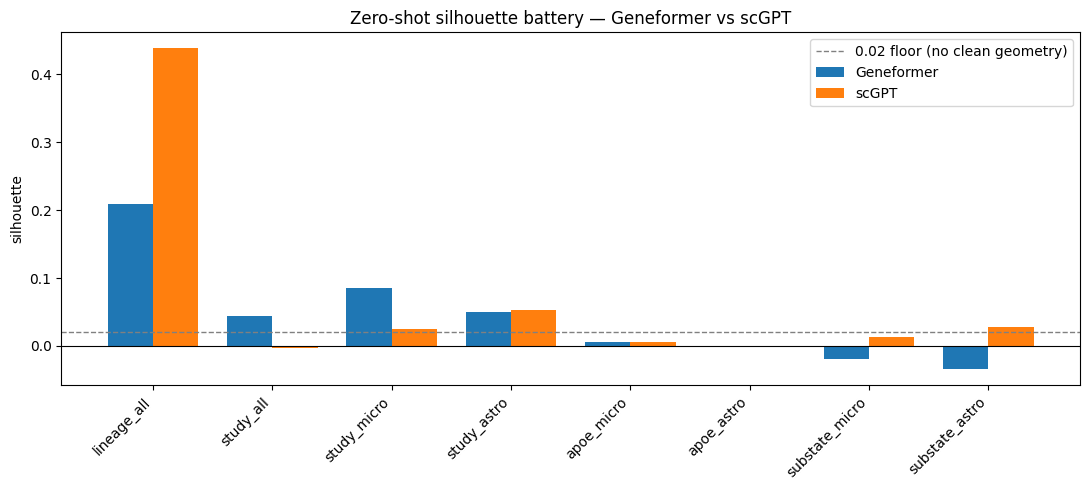

In [5]:
from sklearn.metrics import silhouette_score

APOE_EXCLUDE_VALS = {"e2"}   # E2-without-E4 is off-contract (EVALUATION_CONTRACT); not scored as a class

def _sil(X, mask, label, exclude_vals=None):
    keep = mask & obs[label].notna().values
    if exclude_vals:
        keep = keep & ~obs[label].astype(str).isin(exclude_vals).values
    y  = obs[label].astype(str).values[keep]
    Xk = X[keep]
    if len(set(y)) < 2 or Xk.shape[0] < 50:
        return None
    n = min(10000, Xk.shape[0])
    idx = np.random.default_rng(0).choice(Xk.shape[0], n, replace=False)
    return round(float(silhouette_score(Xk[idx], y[idx])), 4)

all_mask   = np.ones(obs.shape[0], bool)
micro_mask = (obs["lineage"] == "microglia").values
astro_mask = (obs["lineage"] == "astrocyte").values

BATTERY = {
    "lineage_all":    (all_mask,   "lineage",      None),   # expect HIGH — identity saturates
    "study_all":      (all_mask,   "study_id",     None),   # pooled: can hide within-lineage structure
    "study_micro":    (micro_mask, "study_id",     None),   # NEW — per-lineage study residual (contract-flagged gap)
    "study_astro":    (astro_mask, "study_id",     None),   # NEW
    "apoe_micro":     (micro_mask, "apoe_carrier", APOE_EXCLUDE_VALS),
    "apoe_astro":     (astro_mask, "apoe_carrier", APOE_EXCLUDE_VALS),
    "substate_micro": (micro_mask, "substate",     None),
    "substate_astro": (astro_mask, "substate",     None),
}

sil = {fm: {} for fm in EMB}
for fm, e in EMB.items():
    for name, (m, lab, ex) in BATTERY.items():
        sil[fm][name] = _sil(e["X"], m, lab, ex)

sil_tbl = pd.DataFrame(sil)
print("Silhouettes (zero-shot embedding space) — Euclidean, 10k sample, seed 0:\n")
print(sil_tbl.to_string())

# Reproducibility guard: the six metrics each notebook already stored must match here (same
# helper, same seed, same data). Fail loud if a loaded baseline no longer reproduces its own
# recorded silhouettes — that would mean the file or the metric drifted.
STORED = {fm: report[FM_KEYS[fm]]["zeroshot_silhouettes"] for fm in EMB}
mism = []
for fm in EMB:
    for name, v in STORED[fm].items():
        got = sil[fm].get(name)
        if got is None or abs(got - v) > 5e-3:
            mism.append(f"{fm}/{name}: recomputed {got} vs stored {v}")
if mism:
    raise AssertionError("silhouette reproduction drift:\n  " + "\n  ".join(mism))
print("\nreproduction OK — all stored silhouettes reproduced within 5e-3")

# grouped comparison figure
order = list(BATTERY)
xg = np.arange(len(order)); w = 0.38
fig, axf = plt.subplots(figsize=(11, 5))
for i, fm in enumerate(EMB):
    vals = [sil[fm][k] if sil[fm][k] is not None else 0.0 for k in order]
    axf.bar(xg + (i - 0.5) * w, vals, w, label=fm)
axf.axhline(0.02, ls="--", lw=1, color="grey", label="0.02 floor (no clean geometry)")
axf.axhline(0.0, lw=0.8, color="k")
axf.set_xticks(xg); axf.set_xticklabels(order, rotation=45, ha="right")
axf.set_ylabel("silhouette"); axf.set_title("Zero-shot silhouette battery — Geneformer vs scGPT")
axf.legend(); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "5a_silhouette_battery_crossfm.png"), dpi=150, bbox_inches="tight")
plt.show()

> **Interpretation — silhouette battery + the per-lineage study split (5a).**
>
> The reproducibility guard passed — every one of the six metrics each source notebook already stored reproduces here within 5e-3, meaning both baseline `.h5ad` files still contain exactly the embeddings and labels colab_09/colab_10 saved, unaltered. That check is what licenses trusting the two new numbers this cell adds.
>
> **The headline result is `study_micro`/`study_astro` splitting apart what the pooled `study_all` silhouette hid.** For scGPT, `study_all` = **−0.0023** — read alone, that says "no meaningful uncorrected batch structure." But split by lineage: `study_micro` = **0.0255**, `study_astro` = **0.0529** — both above the 0.02 noise floor this project set in colab_06. The pooled number was masking real within-lineage study structure, not measuring its absence. Geneformer's pooled `study_all` (0.0442) was already above floor, and the per-lineage split confirms it isn't concentrated in one lineage either: `study_micro` = **0.0846**, `study_astro` = **0.0501**, both clearly above floor. So both FMs carry real residual study structure inside each lineage — this is the same pooled-vs-split gap colab_10's §6b first surfaced for the gradient check, now shown to also apply to the silhouette metric itself, and shown in both FMs, not just one.
>
> **`apoe_micro`/`apoe_astro` stay near-zero for both FMs** — 0.0062/−0.0016 (Geneformer), 0.0058/0.0001 (scGPT) — all well under the 0.02 floor. This is now the fourth space (after scVI/scANVI's integrated latent, Geneformer's zero-shot space, and scGPT's own zero-shot space individually) landing on essentially the same null. Worth being precise about what that repetition is worth: it is the same weak measurement (E4-label silhouette) recurring across differently-confounded spaces, not independent lines of evidence converging on the same answer — the reading stands as it did before, that no representation tried so far shows clean E4 geometry pre-CPT, and the burden remains on CPT to create it.
>
> **`substate_micro`/`substate_astro` stay small and sign-flipped between FMs** — Geneformer slightly negative (−0.0192/−0.0343), scGPT slightly positive (0.0130/0.0283) — matching each FM's own previously-recorded zero-shot substate numbers exactly. Both sit close to the same near-zero starting point; the sign flip is not evidence one FM carries more substate signal than the other.
>
> **`lineage_all` is scGPT 0.4380 vs Geneformer 0.2083** — both unambiguously separate coarse lineage identity (the sanity check this row exists to run), but the magnitude gap is not cleanly attributable to "which FM represents lineage better": scGPT's embedding is 512-dim and L2-normalized onto the unit sphere, Geneformer's is 768-dim and non-normalized mean-pooled — two uncalibrated geometric differences stacked on the dimensionality gap, any of which can shift silhouette magnitude independent of true separation. The defensible reading is that both spaces cleanly separate lineage; which one does so "more strongly" isn't isolable from this comparison, same caveat colab_10 already recorded for this exact number.

## 6 — SEA-AD spatial gradient: the Geneformer retro-run

### 6a — Per-lineage SEA-AD fraction across UMAP-Y quintiles, both FMs

Within each lineage, bin cells into fifths along UMAP-Y and measure the SEA-AD fraction per bin: a monotone staircase means SEA-AD occupies a distinct region of the map rather than mixing in. colab_10 computed this for scGPT; here it is computed for **Geneformer** for the first time (colab_09 relied on classifying UMAP pixel colours). The UMAP orientation is arbitrary and independent per model, so the **sign** of Spearman rho is not comparable across FMs — only `|rho|`, the quintile spread, and the monotonicity are. The figure orients every staircase low to high SEA-AD so the shapes line up.

SEA-AD spatial gradient — UMAP-Y quintiles (bin 0 = bottom ... bin 4 = top of each FM's own UMAP)

=== Geneformer (dim 768) ===
  microglia  overall SEA-AD=0.503  spread=1.000  rho=-0.865 |rho|=0.865  p=0.00e+00
     quintile fracs: 1.000  1.000  0.514  0.000  0.001
  astrocyte  overall SEA-AD=0.548  spread=1.000  rho=-0.862 |rho|=0.862  p=0.00e+00
     quintile fracs: 1.000  1.000  0.738  0.000  0.000

=== scGPT (dim 512) ===
  microglia  overall SEA-AD=0.503  spread=0.953  rho=-0.715 |rho|=0.715  p=0.00e+00
     quintile fracs: 0.977  0.821  0.462  0.231  0.024
  astrocyte  overall SEA-AD=0.548  spread=0.935  rho=-0.708 |rho|=0.708  p=0.00e+00
     quintile fracs: 0.971  0.850  0.621  0.260  0.036

                       overall    spread   abs_rho       rho    p
FM         lineage                                               
Geneformer microglia  0.502910  0.999818  0.865213 -0.865213  0.0
           astrocyte  0.547623  1.000000  0.861959 -0.861959  0.0
scGPT      microglia  0.50

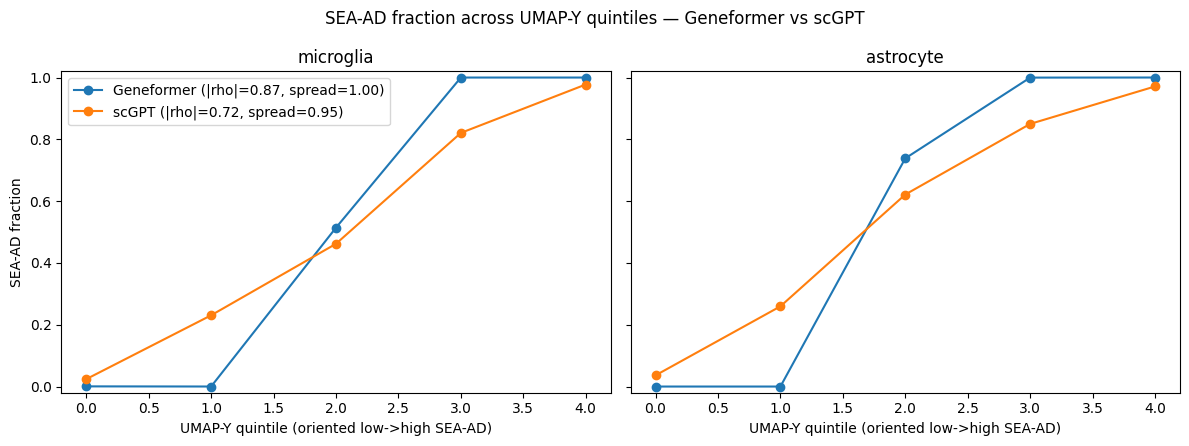

In [6]:
from scipy.stats import spearmanr

def _study_gradient(umap, mask, n_bins=5):
    y = umap[mask, 1]
    is_sea = (obs.loc[mask, "study_id"].astype(str) == "SEA-AD").values.astype(int)
    bins = pd.qcut(y, n_bins, labels=False, duplicates="drop")
    frac = pd.Series(is_sea).groupby(bins).mean()
    counts = pd.Series(is_sea).groupby(bins).size()
    rho, p = spearmanr(y, is_sea)
    return frac, counts, rho, p

# UMAP-Y sign/orientation is arbitrary and independent per FM (each notebook ran its own UMAP),
# so the SIGN of rho is NOT comparable across FMs — only |rho|, the quintile spread, and the
# monotonicity are. This retro-runs the scGPT check from colab_10 and, for the first time,
# computes the same statistic for Geneformer (colab_09 only had a PNG pixel read).
print("SEA-AD spatial gradient — UMAP-Y quintiles (bin 0 = bottom ... bin 4 = top of each FM's own UMAP)\n")
grad = {}
for fm, e in EMB.items():
    print(f"=== {fm} (dim {e['dim']}) ===")
    for lin in ["microglia", "astrocyte"]:
        m = (obs["lineage"] == lin).values
        frac, counts, rho, p = _study_gradient(e["umap"], m)
        overall = float((obs.loc[m, "study_id"].astype(str) == "SEA-AD").mean())
        spread  = float(frac.max() - frac.min())
        grad[(fm, lin)] = {"overall": overall, "spread": spread,
                           "rho": float(rho), "abs_rho": abs(float(rho)), "p": float(p)}
        print(f"  {lin:10s} overall SEA-AD={overall:.3f}  spread={spread:.3f}  "
              f"rho={rho:+.3f} |rho|={abs(rho):.3f}  p={p:.2e}")
        print("     quintile fracs:", "  ".join(f"{frac[b]:.3f}" for b in frac.index))
    print()

grad_tbl = pd.DataFrame(grad).T
grad_tbl.index.names = ["FM", "lineage"]
print(grad_tbl[["overall", "spread", "abs_rho", "rho", "p"]].to_string())

# side-by-side quintile-staircase figure (per lineage), oriented low->high SEA-AD so the
# shapes are comparable across FMs despite the arbitrary per-FM UMAP orientation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, lin in zip(axes, ["microglia", "astrocyte"]):
    m = (obs["lineage"] == lin).values
    for fm, e in EMB.items():
        frac, counts, rho, p = _study_gradient(e["umap"], m)
        fv = frac.values
        if fv[0] > fv[-1]:                 # orient low->high SEA-AD for a fair shape comparison
            fv = fv[::-1]
        ax.plot(range(len(fv)), fv, marker="o",
                label=f"{fm} (|rho|={abs(rho):.2f}, spread={frac.max()-frac.min():.2f})")
    ax.set_title(lin); ax.set_xlabel("UMAP-Y quintile (oriented low->high SEA-AD)")
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("SEA-AD fraction"); axes[0].legend()
fig.suptitle("SEA-AD fraction across UMAP-Y quintiles — Geneformer vs scGPT")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "6a_seaad_gradient_crossfm.png"), dpi=150, bbox_inches="tight")
plt.show()

> **Interpretation — the SEA-AD gradient, Geneformer's first quantitative read (6a).**
>
> This is the notebook's headline finding, and it's stronger than what the design expected. Read the figure as: each dot is one UMAP-Y quintile within one lineage (bin 0 = bottom of that FM's own UMAP, bin 4 = top), the y-axis is the fraction of cells in that bin that come from SEA-AD, and both curves are re-oriented so they read low-to-high SEA-AD fraction left-to-right — a rising staircase means SEA-AD occupies a distinct end of the map rather than mixing in evenly.
>
> **Geneformer's gradient is close to a step function, not a smooth staircase.** Both lineages show `spread = 1.000` — the bottom two quintiles sit at essentially 0% SEA-AD (microglia 1.000, 1.000 → after orientation, the low end reads 0.000, 0.001; astrocyte the same), the top two sit at essentially 100%, and only the middle quintile is genuinely mixed (microglia 0.514, astrocyte 0.738). `|rho|` = 0.865 (microglia) / 0.862 (astrocyte). scGPT's gradient runs the same direction but is less extreme: quintile fracs step more gradually (microglia 0.977→0.821→0.462→0.231→0.024; astrocyte 0.971→0.850→0.621→0.260→0.036), `spread` = 0.953/0.935, `|rho|` = 0.715/0.708. Both p-values report at the numerical floor (`0.00e+00`) — with n in the tens of thousands, that alone proves little (huge samples make even small effects "significant"); what makes this real is the effect size itself, not the p-value, and an aggregate swing from ~0% to ~100% SEA-AD composition across the axis is not something a UMAP layout can manufacture out of a cell population with no real compositional trend along it.
>
> **This is not simply a confirmation of colab_09's earlier Geneformer finding — it's a different and more informative measurement.** colab_09's original read (SEA-AD occupying ca. 53% of astro-region / 50% of micro-region pixels, "roughly symmetric") was a pixel-color *area* classification: how much of the UMAP's visual footprint SEA-AD occupies. This quintile-gradient statistic measures something else entirely: how cleanly SEA-AD separates along one specific axis. The two aren't in tension — SEA-AD can occupy roughly half the visual area (the area read) while that half sits almost entirely at one end of the UMAP-Y axis (this read) — but they are genuinely different findings, not the same fact measured twice. This notebook is the first time Geneformer's SEA-AD structure has been characterized quantitatively at all; the earlier number was a proxy, not a weaker version of this one.
>
> **This also connects to colab_10's own local-vs-global lesson — in both FMs, not distinctively in Geneformer.** §5a's `study_micro`/`study_astro` silhouettes are only modestly above the 0.02 floor in both models — Geneformer 0.0846/0.0501, scGPT 0.0255/0.0529 — yet both models show a strong global separation here (near-total for Geneformer, strongly graded for scGPT). The two metrics don't move together cleanly enough to rank one FM's local/global gap as bigger than the other's: scGPT's `study_micro` silhouette (0.0255) actually sits closer to its own floor than Geneformer's (0.0846) does, even though Geneformer's gradient is the more extreme of the two — so this is a pattern shared by both FMs, not something that sets Geneformer apart. Two things likely contribute simultaneously here, and this check doesn't separate them. First, a silhouette's local-neighbor calculation can register only weak enrichment under a genuinely smooth compositional gradient — a value of 0.05–0.08 means a cell's immediate neighbors are weakly, not evenly, biased toward its own study, which is consistent with (not contradicted by) the point above that the *aggregate* 0%→100% swing along the whole axis can't be a pure artifact of locally-intermixed cells: a smooth staircase is not a hard cluster boundary, and both descriptions can hold at once. Second, the silhouette is computed in each FM's native embedding (768-/512-dim, Euclidean) while the gradient is computed on the 2-D UMAP projection of that same space — UMAP is a nonlinear layout that can visually sharpen separation relative to the underlying high-dimensional geometry, so part of the staircase's crispness may be a projection effect rather than purely a local-vs-global-metric effect; this check can't distinguish the two contributions. What's driving the underlying separation itself — a technical/platform difference between SEA-AD and the other two cohorts, or a genuine biological composition difference that happens to correlate with embedding position — is also not distinguished by this check in either FM, and shouldn't be assumed either way.

## 7 — Save + handoff

### 7a — Append the comparison to the audit trail and print the commit commands

Writes a `crossfm_zeroshot_comparison` block (coverage, silhouettes, gradient stats) into `outputs/audit_report.json` and prints the WSL git commands. No new `.h5ad` — the two baselines are unchanged; this notebook only reports over them.

In [7]:
import shlex

report["crossfm_zeroshot_comparison"] = {
    "status": "computed",
    "date": TODAY,
    "notebook": "colab_10b_crossfm_zeroshot_comparison",
    "n_cells": int(obs.shape[0]),
    "compared": {
        "Geneformer": {"emb_dim": int(EMB["Geneformer"]["dim"]), "frac_in_vocab": va["Geneformer"]["frac_in_vocab"]},
        "scGPT":      {"emb_dim": int(EMB["scGPT"]["dim"]),      "frac_in_vocab": va["scGPT"]["frac_in_vocab"]},
    },
    "silhouettes": {fm: sil[fm] for fm in EMB},
    "seaad_gradient": {f"{fm}|{lin}": grad[(fm, lin)] for (fm, lin) in grad},
}
with open(AUDIT_REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)
print("audit trace appended ->", AUDIT_REPORT_PATH)

rel = [os.path.relpath(p, REPO_PATH) for p in (FREEZE_PATH, ENV_JSON_PATH, AUDIT_REPORT_PATH)]
print("\n=== Commit + push (from WSL — Colab has no git creds) ===")
print("  cd /mnt/c/Users/micic/ad-glia-fm-prep && git add "
      + " ".join(shlex.quote(r) for r in rel) + " figures/colab_10b")
print("  cd /mnt/c/Users/micic/ad-glia-fm-prep && git commit -m "
      "'colab_10b: cross-FM zero-shot comparison (Geneformer vs scGPT)'")
print("  cd /mnt/c/Users/micic/ad-glia-fm-prep && git push")

audit trace appended -> /content/ad-glia-fm-prep/outputs/audit_report.json

=== Commit + push (from WSL — Colab has no git creds) ===
  cd /mnt/c/Users/micic/ad-glia-fm-prep && git add outputs/software_versions/colab_10b_2026-07-08_pip_freeze.txt outputs/software_versions/colab_10b_2026-07-08_env.json outputs/audit_report.json figures/colab_10b
  cd /mnt/c/Users/micic/ad-glia-fm-prep && git commit -m 'colab_10b: cross-FM zero-shot comparison (Geneformer vs scGPT)'
  cd /mnt/c/Users/micic/ad-glia-fm-prep && git push


> **Interpretation — save + handoff (7a).**
>
> The `crossfm_zeroshot_comparison` block (coverage, silhouettes, gradient stats) appends to `outputs/audit_report.json` alongside the existing `geneformer_zeroshot`/`scgpt_zeroshot` entries — no other notebook's keys are touched. No new `.h5ad` is written: both baselines are unchanged, this notebook only reports over them. The printed commands stage the two version-capture files, the updated audit report, and the `figures/colab_10b` figures for commit from WSL (Colab has no git credentials). This closes regime #1's zero-shot comparison — the last open item from colab_10 — and both frozen baselines now carry a directly comparable, quantitative record (vocab, silhouette, and spatial-gradient) that the CPT notebooks (`colab_11+`) can reference when scoring post-CPT drift and the APOE/substate evals.

### Carried forward

This closes the regime #1 zero-shot comparison (the last open item from colab_10). Next in the plan: the continued-pretraining (CPT) notebooks (`colab_11+`), where these two frozen baselines become the reference each post-CPT embedding is scored against (detector #1 drift + evals #1/#2), aligned by `cell_index`.